# Roman Coronagraph Contrast Curves

This sheet demonstrates how to generate observing mode 'contrast curves' - achievable flux ratios as functions of integration time and 'saturation curves' - achievable flux ratios for infinite integration time (this is a measure of the system noise floor or contrast stability).

The final figure in this notebook appears in Savransky et al. (2026) Proc. SPIE.  Please cite this paper if utilizing this figure or any figure derived from this code. 


If running via Google Colab, you must first execute the contents of notebook `00_Google_Colab_Setup.ipynb` (only if you have never done so previously). Then execute all cells tagged with &#128992;.  If running via a local installation, you should skip all of the colab-specific (&#128992;) cells.

## 🟠 Setup for Google Colab Use

### 🟠 Run the next cell to mount the Google Drive

You will receive some or all of the following prompts:

* Warning: This notebook was not authored by Google - Click "Run Anyway" 
* Permit this notebook to access your Google Drive files? - Click "Connect to Google Drive"
* A new browser window will prompt you to select an account and authorize access
  * Select the Google account you wish to use and click Continue on each subsequent screen until the dialog vanishes

Upon completion of cell execution, you should see `Mounted at /content/drive`

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### 🟠 Run the next cell to change to the corgietc directory and install the required software

This process should take less than a minute, but, depending on bandwidth availability, may take as long as a few minutes. You will see a variety of messages about package downloads.  Upon completion of cell execution, you should see `Sucessfully installed` followed by a list of installed packages and their versions.

You may see the prompt "Restart session".  You do not need to do this - click 'Cancel'.

In [ ]:
# This cell should *only* be executed if running the notebook in Google Colab
import os

# Google top level drive dir
drive_dir = "/content/drive/MyDrive/"

# directory path
corgietc_dir = 'corgietc'
corgietc_path = os.path.join(drive_dir, corgietc_dir)
cgi_noise_repo_path = os.path.join(corgietc_path, "cgi_noise")
corgietc_repo_path = os.path.join(corgietc_path, "corgietc")
corgietc_notebooks_path = os.path.join(corgietc_repo_path, "Notebooks")

# Change to the cgi_noise repo path and update the repo
os.chdir(cgi_noise_repo_path)
!git pull

# Install the backend and all requirements - this can also take a little while
!pip install .

# Change to the corgietc repo path and update the repo
os.chdir(corgietc_repo_path)
!git pull

# Install the backend and all requirements - this can also take a little while
!pip install .

# Refresh package list to pick up new installations
import site
site.main()

# Change to the Notebooks directory
os.chdir(corgietc_notebooks_path)

### 🟠 Import jupyter widget for Colab

In [ ]:
# need to import third party jupyter widget
from google.colab import output
output.enable_custom_widget_manager()

## All Cells from this point should be run for both Colab and local installations

In [1]:
# import all required packages
import corgietc
import os
import json
import EXOSIMS.Prototypes.TargetList
import EXOSIMS.Prototypes.TimeKeeping
import copy
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import pandas
from matplotlib.legend_handler import HandlerTuple

In [2]:
# set up objects - see Notebook 01 for details
scriptfile = os.path.join(os.environ["CORGIETC_DATA_DIR"], "scripts", "CGI_Noise.json")
with open(scriptfile, "r") as f:
    specs = json.loads(f.read())

TK = EXOSIMS.Prototypes.TimeKeeping.TimeKeeping(
    missionLife=5.25
)  # 63 months in years is 5.25, 21 months is 1.75
TK.allocate_time(21 * 30.4375 * u.d)
TL = EXOSIMS.Prototypes.TargetList.TargetList(**copy.deepcopy(specs))
OS = TL.OpticalSystem

# set fixed inputs
sInds = 0
fZ = np.repeat(TL.ZodiacalLight.fZ0, 1)
mode = OS.observingModes[0]
JEZ = TL.JEZ0[mode["hex"]] / (4.1536**2)

OBendTimes is: [1917.5625] d


/Users/ds264/Documents/gitrepos/EXOSIMS/EXOSIMS/Prototypes/TargetList.py:381: UserWarning: binary_filter is None but filterBinaries is False. Using binary_filter value of None.
  warnings.warn(


Imported StarCatalog (prototype) from EXOSIMS.Prototypes.StarCatalog
Imported corgietc (named file) from /Users/ds264/Do[...]ietc/corgietc/corgietc.py
Imported Stark (implementation) from EXOSIMS.ZodiacalLight.Stark
Imported PostProcessing (prototype) from EXOSIMS.Prototypes.PostProcessing
Imported GalaxiesFaintStars (implementation) from EXOSIMS.BackgroundSources.GalaxiesFaintStars
Imported Completeness (prototype) from EXOSIMS.Prototypes.Completeness
Imported PlanetPopulation (prototype) from EXOSIMS.Prototypes.PlanetPopulation
Imported ForecasterMod (implementation) from EXOSIMS.PlanetPhysicalModel.ForecasterMod
1 targets imported from star catalog.
1 targets remain after removing those where spectral class cannot be established.
1 targets remain after removing white dwarfs and subdwarfs
1 targets remain after nan filtering.
1 targets remain after removing zero luminosity targets.
Loaded JEZ0 for mode e0801f22e5abd19dc9f9ed6a72afd219 from /Users/ds264/.EXOSIMS/cache/v3.6.5/TargetLis

For our fiducial calculation, we will assume 1, 10, and 100 hours for imaging modes and 5, 50, and 500 hours for spectroscopy modes.

In [3]:
# loop through all modes and time combinations
# NB: This may take a while
sat_dMags = {}
inv_dMags = {}
for mode in OS.observingModes:
    WAs = (
        np.linspace(mode["IWA"].value * 1.01, mode["OWA"].value * 0.99, 100)
        * mode["IWA"].unit
    )
    sat_dMags[mode["Scenario"]] = OS.calc_saturation_dMag(
        TL,
        [sInds] * len(WAs),
        np.repeat(fZ, len(WAs)),
        np.repeat(JEZ, len(WAs)),
        WAs,
        mode,
        TK=TK,
    )

    if "SPEC" in mode["Scenario"]:
        times_hrs = [5, 50, 500]
    else:
        times_hrs = [1, 10, 100]

    for t_hr in times_hrs:
        inv_dMags[(mode["Scenario"], t_hr)] = OS.calc_dMag_per_intTime(
            np.ones(len(WAs)) * t_hr * u.hr,
            TL,
            [sInds] * len(WAs),
            np.repeat(fZ, len(WAs)),
            np.repeat(JEZ, len(WAs)),
            WAs,
            mode,
            TK=TK,
        )

        # consistency check
        itimes = OS.calc_intTime(
            TL,
            [sInds] * len(WAs),
            fZ,
            JEZ,
            inv_dMags[(mode["Scenario"], t_hr)],
            WAs,
            mode,
            TK=TK,
        )
        assert np.max(np.abs((itimes.to(u.hr) - t_hr * u.hr))) < 20 * u.s

Computing dMags: 100%|████████████████████████| 100/100 [00:09<00:00, 10.02it/s]


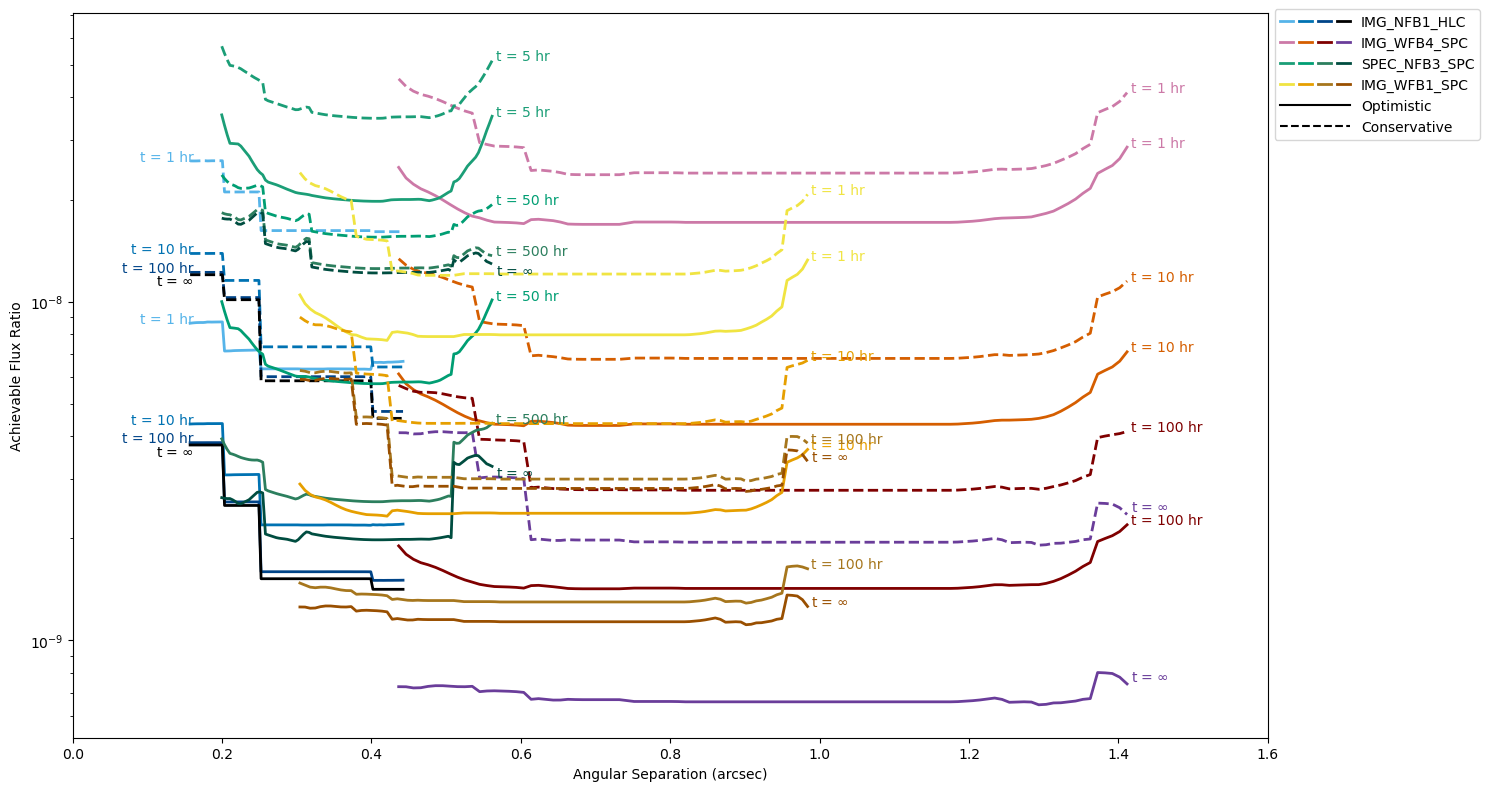

In [4]:
# generate plot
plt.figure(figsize=(15, 8))
legend_groups = {}
for mode in OS.observingModes:
    shortname = "_".join(mode["Scenario"].split("_")[1:])
    WAs = (
        np.linspace(mode["IWA"].value * 1.01, mode["OWA"].value * 0.99, 100)
        * mode["IWA"].unit
    )
    va = "baseline" # default vertical alignment for annotation text
    # set color groups and location of annotation by mode 
    if "IMG_NFB1_HLC" in mode["Scenario"]:
        cs = ["#56B4E9", "#0072B2", "#004488", "#000000"]
        annot_index = 0
        va = "top"
    elif "IMG_WFB4_SPC" in mode["Scenario"]:
        cs = ["#CC79A7", "#D55E00", "#7F0000", "#6A3D9A"]
        annot_index = -1
        va = "bottom"
    elif "SPEC_NFB3_SPC" in mode["Scenario"]:
        cs = ["#1B9E77", "#009E73", "#2C7F5E", "#004D40"]
        annot_index = -1
        va = "top"
    else:
        cs = ["#F0E442", "#E69F00", "#A6761D", "#994F00"]
        annot_index = -1

    # optimistic modes are plotted with solid lines
    # conservative modes are plotted with dashed lines
    if "CON" in mode["Scenario"]:
        lstyle = "--"
    else:
        lstyle = "-"

    # set horizontal alignments
    if annot_index == 0:
        ha = "right"
    else:
        ha = "left"

    # plot time curves
    if "SPEC" in mode["Scenario"]:
        times_hrs = [5, 50, 500]
    else:
        times_hrs = [1, 10, 100]
    for jj, t_hr in enumerate(times_hrs):
        tmp = plt.semilogy(
            WAs.value,
            10 ** (-0.4 * inv_dMags[(mode["Scenario"], t_hr)]),
            lstyle,
            linewidth=2,
            color=cs[jj],
        )
        plt.annotate(
            f"t = {t_hr} hr",
            (
                WAs[annot_index].value + 0.005,
                10 ** (-0.4 * inv_dMags[(mode["Scenario"], t_hr)][annot_index]),
            ),
            color=cs[jj],
            ha=ha,
        )
        if "CON" not in mode["Scenario"]:
            if jj == 0:
                legend_groups[shortname] = [
                    tmp[0],
                ]
            else:
                legend_groups[shortname].append(tmp[0])

    # plot saturation curves
    tmp = plt.semilogy(
        WAs.value,
        10 ** (-0.4 * sat_dMags[mode["Scenario"]]),
        lstyle,
        color=cs[-1],
        linewidth=2,
        label=rf"{mode['Scenario']} t = $\infty$",
    )
    if "CON" not in mode["Scenario"]:
        legend_groups[shortname].append(tmp[0])

    plt.annotate(
        r"t = $\infty$",
        (
            WAs[annot_index].value + 0.005,
            10 ** (-0.4 * sat_dMags[mode["Scenario"]][annot_index]),
        ),
        color=cs[-1],
        ha=ha,
        va=va,
    )

# for legend only
(optp,) = plt.plot(0, 0, "k")
(conp,) = plt.plot(0, 0, "k--")

# create grouped legend entries
handles = [tuple(legend_groups[k]) for k in legend_groups]
handles.extend([optp, conp])
labels = list(legend_groups.keys())
labels.extend(["Optimistic", "Conservative"])
plt.legend(
    handles=handles,
    labels=labels,
    handler_map={tuple: HandlerTuple(ndivide=None)},
    handlelength=5,
    bbox_to_anchor=(1, 1.015),
)

# label axes and cleanup
plt.xlabel("Angular Separation (arcsec)")
plt.ylabel("Achievable Flux Ratio")
plt.xlim(0, 1.6)
plt.tight_layout()

You may also write the results out to disk.  To run this code, you will need to have the `xlsxwriter` and/or `openpyxl` Python packages installed. 

In [ ]:
with pandas.ExcelWriter("intTime_curves.xlsx") as writer:
    # loop through modes and create separate sheets for each
    for mode in OS.observingModes:
        WAs = (
            np.linspace(mode["IWA"].value * 1.01, mode["OWA"].value * 0.99, 100)
            * mode["IWA"].unit
        )
        out = pandas.DataFrame(
            {
                "WA (arcsec)": WAs.value,
                "WA (lambda/D)": (WAs / mode["syst"]["input_angle_unit_value"]).value,
            }
        )
        if "SPEC" in mode["Scenario"]:
            times_hrs = [5, 50, 500]
        else:
            times_hrs = [1, 10, 100]
        for t_hr in times_hrs:
            out[f"t = {t_hr} hr"] = inv_dMags[(mode["Scenario"], t_hr)]
        out["Infinite Time"] = sat_dMags[mode["Scenario"]]
        out.to_excel(writer, sheet_name=mode["Scenario"], index=False)